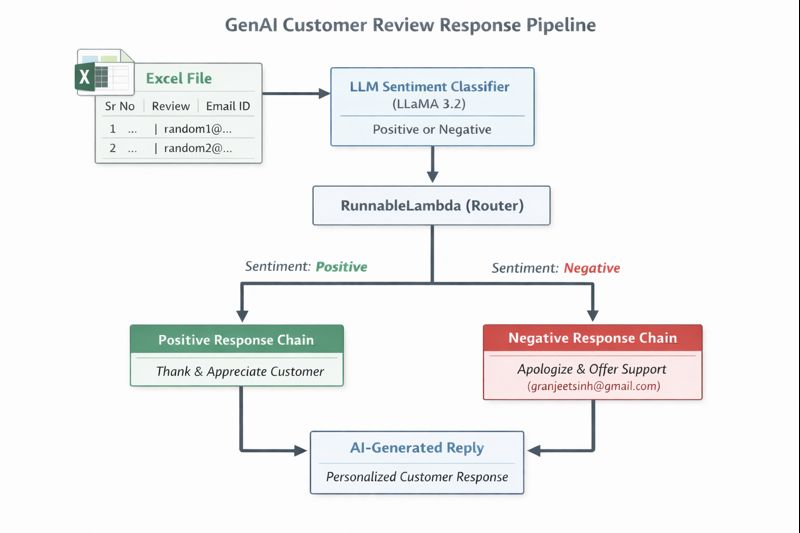
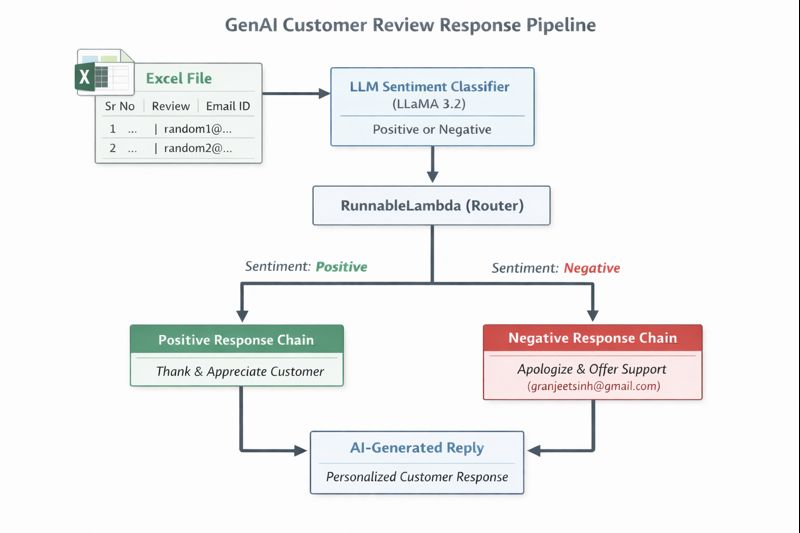

In [3]:
import os
print(os.getcwd())


/Users/ranjitsinhshridharraogutte/Documents/GenAI Based Customer Review Response System


In [4]:
csv_path = os.path.join("04. Chains", "04.1 Mini Project", "water_bottle_reviews.csv")

In [5]:
import pandas as pd

# Step 1: Read the CSV file using your relative path
csv_path = "water_bottle_reviews.csv"


df = pd.read_csv(csv_path)

# Step 2: Convert rows into structured review objects
reviews = []

for _, row in df.iterrows():
    review_obj = {
        "sr_no": int(row["sr_no"]),
        "product": "Water Bottle",
        "review": str(row["review"]).strip(),
        "email": str(row["email"]).strip()
    }
    reviews.append(review_obj)

# Step 3: Verify output (print first 3 for sanity check)
for r in reviews[:3]:
    print(r)


{'sr_no': 1, 'product': 'Water Bottle', 'review': 'The water bottle quality is excellent and feels premium.', 'email': 'amit.patil01@gmail.com'}
{'sr_no': 2, 'product': 'Water Bottle', 'review': 'Keeps water cold for hours, very happy with the purchase.', 'email': 'neha.sharma22@gmail.com'}
{'sr_no': 3, 'product': 'Water Bottle', 'review': 'Leak-proof and lightweight, perfect for daily use.', 'email': 'rohit.kulkarni77@gmail.com'}


In [6]:
reviews

[{'sr_no': 1,
  'product': 'Water Bottle',
  'review': 'The water bottle quality is excellent and feels premium.',
  'email': 'amit.patil01@gmail.com'},
 {'sr_no': 2,
  'product': 'Water Bottle',
  'review': 'Keeps water cold for hours, very happy with the purchase.',
  'email': 'neha.sharma22@gmail.com'},
 {'sr_no': 3,
  'product': 'Water Bottle',
  'review': 'Leak-proof and lightweight, perfect for daily use.',
  'email': 'rohit.kulkarni77@gmail.com'},
 {'sr_no': 4,
  'product': 'Water Bottle',
  'review': 'Design is stylish and easy to carry while traveling.',
  'email': 'priya.desai88@gmail.com'},
 {'sr_no': 5,
  'product': 'Water Bottle',
  'review': 'Very durable bottle, worth the price.',
  'email': 'ankit.mehta19@gmail.com'},
 {'sr_no': 6,
  'product': 'Water Bottle',
  'review': 'The cap fits perfectly and does not spill at all.',
  'email': 'snehal.jadhav55@gmail.com'},
 {'sr_no': 7,
  'product': 'Water Bottle',
  'review': 'I love this bottle, great insulation performance.',

In [7]:
import csv
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM setup
llm = ChatOllama(
    base_url="http://localhost:11434",
    model="llama3.2:latest"
)

# Prompt
sentiment_prompt = ChatPromptTemplate.from_template("""
You are a sentiment classifier.

Classify the following customer review as either:
- positive
- negative

Return ONLY one word: positive or negative.

Review:
{review}
""")

sentiment_chain = sentiment_prompt | llm | StrOutputParser()

# Function to add sentiment
def add_sentiment(review_obj):
    sentiment = sentiment_chain.invoke(
        {"review": review_obj["review"]}
    ).strip().lower()

    review_obj["sentiment"] = sentiment
    return review_obj


In [8]:
reviews_with_sentiment = []

with open("water_bottle_reviews.csv", newline="", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        review_obj = {
            "sr_no": int(row["sr_no"]),
            "email": row["email"],
            "product": "Water Bottle",
            "review": row["review"]
        }

        review_obj = add_sentiment(review_obj)
        reviews_with_sentiment.append(review_obj)


In [9]:
reviews_with_sentiment

[{'sr_no': 1,
  'email': 'amit.patil01@gmail.com',
  'product': 'Water Bottle',
  'review': 'The water bottle quality is excellent and feels premium.',
  'sentiment': 'positive'},
 {'sr_no': 2,
  'email': 'neha.sharma22@gmail.com',
  'product': 'Water Bottle',
  'review': 'Keeps water cold for hours, very happy with the purchase.',
  'sentiment': 'positive.'},
 {'sr_no': 3,
  'email': 'rohit.kulkarni77@gmail.com',
  'product': 'Water Bottle',
  'review': 'Leak-proof and lightweight, perfect for daily use.',
  'sentiment': 'positive.'},
 {'sr_no': 4,
  'email': 'priya.desai88@gmail.com',
  'product': 'Water Bottle',
  'review': 'Design is stylish and easy to carry while traveling.',
  'sentiment': 'positive.'},
 {'sr_no': 5,
  'email': 'ankit.mehta19@gmail.com',
  'product': 'Water Bottle',
  'review': 'Very durable bottle, worth the price.',
  'sentiment': 'positive'},
 {'sr_no': 6,
  'email': 'snehal.jadhav55@gmail.com',
  'product': 'Water Bottle',
  'review': 'The cap fits perfectly

🧭 Step 4 – RunnableLambda Routing

🎯 Goal

Based on the sentiment, automatically route the review object to:

✅ Positive response chain

❌ Negative response chain

WITHOUT:

Losing sr_no

Losing email

Mixing customers

🧠 Key Design Rule (Very Important)

Routing logic must be deterministic Python code,
NOT handled by the LLM.

- LLM = text generation
- Python = decision making

- review_with_sentiment
        ↓
- RunnableLambda (router)
        ↓
- positive_chain OR negative_chain
        ↓
- final_response


In [10]:
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


- Positive Response Chain

In [11]:
positive_prompt = ChatPromptTemplate.from_template("""
You are a customer support assistant.

Write a polite response thanking the customer for their positive feedback
and expressing gratitude and appreciation.

Customer Review:
{review}
""")

positive_chain = positive_prompt | llm | StrOutputParser()


- Negative Response Chain

In [12]:
negative_prompt = ChatPromptTemplate.from_template("""
You are a customer support assistant.

Write a polite response apologizing for the customer's experience.
Assure them that we will improve the product.
Ask them to contact us at granjeetsinh@gmail.com for further support.

Customer Review:
{review}
""")

negative_chain = negative_prompt | llm | StrOutputParser()


- Router Function (Your Original Idea – Correct ✅)

In [13]:
def route(info):
    if "positive" in info["sentiment"].lower():
        return positive_chain
    else:
        return negative_chain


- RunnableLambda Router

In [14]:
router = RunnableLambda(route)


- Full Routing Chain (Clean & Elegant)

In [15]:
full_chain = {
    "review": lambda x: x["review"],
    "sentiment": lambda x: x["sentiment"]
} | router


In [16]:
def generate_response(review_obj):
    response = full_chain.invoke(review_obj)
    review_obj["ai_response"] = response
    return review_obj


- Passing one review to see if it works

In [17]:
test_review = {
    "sr_no": 8,
    "email": "test@gmail.com",
    "product": "Water Bottle",
    "review": "The bottle leaks after one week",
    "sentiment": "negative"
}

print(generate_response(test_review))


{'sr_no': 8, 'email': 'test@gmail.com', 'product': 'Water Bottle', 'review': 'The bottle leaks after one week', 'sentiment': 'negative', 'ai_response': "Dear valued customer,\n\nI am writing to express my sincerest apologies for the inconvenience you have experienced with your recent purchase. We are deeply sorry to hear that the bottle has leaked after only one week of use, and we understand how frustrating this must be for you.\n\nAt [Company Name], we take all feedback seriously and are truly sorry that our product did not meet your expectations. We want to assure you that we are taking immediate action to address this issue and make necessary improvements to prevent such incidents in the future.\n\nWe value your feedback and would like to invite you to contact us directly at granjeetsinh@gmail.com so that we can further discuss this matter with you and provide any assistance needed. Your input is invaluable in helping us improve our products and services.\n\nOnce again, please acce

- Now passing each classified to full chain

In [18]:
final_reviews = []

for review_obj in reviews_with_sentiment:
    response = full_chain.invoke(review_obj)
    review_obj["ai_response"] = response
    final_reviews.append(review_obj)


In [19]:
final_reviews

[{'sr_no': 1,
  'email': 'amit.patil01@gmail.com',
  'product': 'Water Bottle',
  'review': 'The water bottle quality is excellent and feels premium.',
  'sentiment': 'positive',
  'ai_response': "Dear [Customer],\n\nI wanted to take a moment to express my heartfelt thanks for taking the time to share your wonderful review about our water bottle. We are thrilled to hear that you're satisfied with its quality and feel, and we couldn't be more grateful for your kind words.\n\nAt [Company Name], we strive to deliver exceptional products that exceed our customers' expectations, and it's customers like you who make all the hard work worthwhile. Your positive feedback means the world to us, and we will definitely take your comments into consideration as we continue to improve and innovate our products.\n\nOnce again, thank you for your kind review and for choosing [Company Name]. We're honored to have customers like you who appreciate our brand and products.\n\nBest regards,\n[Your Name]\nCu

## Runnable Lambda

My question to chatgpt was
- while explaining you told that LangChain cannot call a normal Python function inside a chain. Does it mean that runnable lambda is used to pass output of one llm to another. if i am wrong correct me

❌ What RunnableLambda is NOT

❌ “RunnableLambda is used to pass output of one LLM to another LLM”

This is not fully correct.

LLMs can already pass outputs to other LLMs without RunnableLambda.

Example (no RunnableLambda needed):

chain = prompt1 | llm | prompt2 | llm


So RunnableLambda is NOT required for LLM → LLM flow.

✅ What RunnableLambda ACTUALLY is (Correct Understanding)

RunnableLambda is used to insert NORMAL PYTHON LOGIC
inside a LangChain pipeline.



That’s the key idea.

🧠 Think of LangChain as a conveyor belt 🏭

On the conveyor belt:

- Prompts are allowed

- LLMs are allowed

- Output parsers are allowed

But plain Python if/else, dict access, math, routing
❌ are NOT allowed directly.

🧩 Where RunnableLambda fits

RunnableLambda is a bridge between:

LangChain world  <---->  Python world




It allows you to say:

“Hey LangChain, pause here and let me run my Python logic.”

🔍 What your router REALLY does

def route(info):
    if info["sentiment"] == "positive":
        return positive_chain
    else:
        return negative_chain


This function:

- Does NOT call an LLM

- Does NOT generate text

- Does NOT transform text

- It only decides WHAT should run next.

LangChain itself cannot make this decision, because:

- LLM output is text

- Routing requires deterministic logic

🧠 Correct Mental Model (Important 🔒)
| Thing            | Role                              |
|------------------|-----------------------------------|
| LLM              | Generate text                     |
| Chain            | Sequence of steps                 |
| RunnableLambda   | Run Python logic inside a chain   |
| Router           | Choose next chain                 |
| Loop             | Handle multiple items             |


🧪 Why not let LLM decide routing?

Because LLMs:

- Can hallucinate

- Can be inconsistent

- Are probabilistic

Routing must be:

- Deterministic

- Predictable

- Safe

So routing belongs in Python, not AI.

## 🏁 Final Correct Statement

**RunnableLambda** is used to insert **deterministic Python logic**  
*(like routing, filtering, validation, transformation)*  
inside a **LangChain pipeline**.

**❌ NOT:**  
RunnableLambda is used to connect LLMs.

---

## 💡 One-Sentence Clarity (Beginner Gold)

> **LLMs think, RunnableLambda decides.**


## Step 5

In [21]:
import csv

output_file = "water_bottle_reviews_with_responses.csv"

fieldnames = [
    "sr_no",
    "email",
    "product",
    "review",
    "sentiment",
    "ai_response"
]

with open(output_file, mode="w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()

    for review in final_reviews:
        writer.writerow(review)
